## MODELING DETERMINANTS OF ANTENATAL VISITS IN KENYA USING POISSON REGRESSION

### **Introduction**  
This report aims to assess the determinants of antenatal care visits using the Poisson and negative binomial regression models. The dependent variable will be antenatal care (ANC) visits which is a count variable. Whereas WHO recommends a minimum of 8 visits, Kenya continues to lag behind with an average of just 4 visits. A statistical analysis of these determinants will highlight which are most impactful thus laying a foundation for accurate and evidence-based recoommendations for policy formulation and improvement of the country's health and specifically maternal sector.

In [1]:
#import libraries to be used 
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy import stats 

In [ ]:
#Importing the dataset
import re
import pandas as pd

# === Step 1: Parse the .SAS file ===
sas_file = "KENR8CFL.SAS"
with open(sas_file, "r", encoding="latin-1") as f:
    lines = f.readlines()

colspecs = []
names = []
inside_input = False

# Extract variable definitions from the INPUT block
for line in lines:
    if line.strip().upper().startswith("INPUT"):
        inside_input = True
        continue
    if inside_input:
        if ";" in line:
            break  # End of INPUT block
        match = re.search(r"@(\d+)\s+(\w+)\s+([$]?)(\d+)\.0", line)
        if match:
            start = int(match.group(1)) - 1  # Convert to 0-based indexing
            name = match.group(2)
            width = int(match.group(4))
            end = start + width
            colspecs.append((start, end))
            names.append(name)

# Optional fix if first variable (e.g., CASEID) was missed
if names and names[0] != "CASEID":
    colspecs.insert(0, (0, 15))
    names.insert(0, "CASEID")

# === Step 2: Read the .DAT file using colspecs ===
dat_file = "KENR8CFL.DAT"
df = pd.read_fwf(dat_file, colspecs=colspecs, names=names, encoding="latin-1")

# === Step 3: Preview or use the DataFrame ===
print(df.head())


     CASEID  PIDX  V001  V002  V003  V004     V005  V006  V007  V008  ...  \
0  1   4  2     1     1     4     2     1  1296049     4  2022  1468  ...   
1  1   7  2     1     1     7     2     1  1296049     4  2022  1468  ...   
2  1  55  2     1     1    55     2     1  1296049     4  2022  1468  ...   
3  1  55  2     2     1    55     2     1  1296049     4  2022  1468  ...   
4  1  65  2     1     1    65     2     1  1296049     4  2022  1468  ...   

   SDV30BN  SDV30BX  SDV30BZ  SDV35A  SREDUC  SPEDUC  IDX94  IDX94P  S446  \
0      NaN      NaN      NaN     0.0       0     0.0      1       1   2.0   
1      NaN      NaN      NaN     NaN       2     3.0      0       1   NaN   
2      NaN      NaN      NaN     0.0       2     4.0      1       1   NaN   
3      NaN      NaN      NaN     0.0       2     4.0      2       2   NaN   
4      NaN      NaN      NaN     NaN       2     2.0      1       1   1.0   

   S454A  
0  203.0  
1    NaN  
2  206.0  
3    NaN  
4  307.0  

[5 rows

In [ ]:
#convert file to csv for easier working
df.to_csv("KENR8CFL.csv", index=False, encoding="utf-8")

In [ ]:
#read the dataframe using pd.read_csv() function
df = pd.read_csv("KENR8CFL.csv")
df

In [3]:
df.head()

,CASEID,PIDX,V001,V002,V003,V004,V005,V006,V007,V008,...,SDV30BN,SDV30BX,SDV30BZ,SDV35A,SREDUC,SPEDUC,IDX94,IDX94P,S446,S454A
0,1 4 2,1,1,4,2,1,1296049,4,2022,1468,...,NaN,NaN,NaN,0.0,0,0.0,1,1,2.0,203.0
1,1 7 2,1,1,7,2,1,1296049,4,2022,1468,...,NaN,NaN,NaN,NaN,2,3.0,0,1,NaN,NaN
2,1 55 2,1,1,55,2,1,1296049,4,2022,1468,...,NaN,NaN,NaN,0.0,2,4.0,1,1,NaN,206.0
3,1 55 2,2,1,55,2,1,1296049,4,2022,1468,...,NaN,NaN,NaN,0.0,2,4.0,2,2,NaN,NaN
4,1 65 2,1,1,65,2,1,1296049,4,2022,1468,...,NaN,NaN,NaN,NaN,2,2.0,1,1,1.0,307.0


In [60]:
#load, open and view the map file with the full descriptions of the variables
with open('KENR8CFL.MAP', 'r', encoding="ISO-8859-1") as file:
    sas_code = file.read()
    print(sas_code)

                                                   KENR8CFL                                                   
                                                KENR8CFL_DICT                                                 

                                             KENR8CFL.DCF                                                     
                                    Last Modified:  8/12/2024  1:03:00 PM                                     

--------------------------------------------------------------------------------------------------------------
Level Name                    Level Label                                                  Type            Rec
  Record Name                   Record Label                                              Value  Req  Max  Len
--------------------------------------------------------------------------------------------------------------
HOUSEHOLD                     HOUSEHOLD                                                                       

In [6]:
# Define the columns to keep (from Word documents)
selected_columns = [ "CASEID", "M14", "V013", "SREDUC", "V501", "V190", "V714", "V025", "V483A", "M15", "V155", "PORD", "V743A", "M2N", "V176"]

#selected_columns = ["Number of antenatal visits during pregnancy", 
#"Respondent's current age", "Respondent education",
# "current marital status", "Wealth index combined", "Respondent currently working", "Type of place of residence",
# "Minutes to healthcare", "Place of delivery", "Covered by health insurance",
#"Literacy", "Mode of transport to nearest healthcare"]

In [7]:
# Select only those columns (check if they exist in case of naming issues)
df_selected = df[selected_columns]

In [8]:
df_selected["CASEID"] = df_selected["CASEID"].astype("category")

C:\Users\pc\AppData\Local\Temp\ipykernel_476\994183819.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["CASEID"] = df_selected["CASEID"].astype("category")


In [9]:
df_selected.dtypes

CASEID    category
M14        float64
V013         int64
SREDUC       int64
V501         int64
V190         int64
V714         int64
V025         int64
V483A      float64
M15        float64
V155         int64
PORD         int64
V743A      float64
M2N        float64
V176         int64
dtype: object

In [10]:
df_selected.head()

,CASEID,M14,V013,SREDUC,V501,V190,V714,V025,V483A,M15,V155,PORD,V743A,M2N,V176
0,1 4 2,5.0,4,0,1,4,0,1,30.0,21.0,0,4,4.0,0.0,1
1,1 7 2,NaN,5,2,1,5,0,1,NaN,NaN,2,2,4.0,NaN,2
2,1 55 2,3.0,4,2,1,5,0,1,NaN,21.0,2,3,1.0,0.0,3
3,1 55 2,NaN,4,2,1,5,0,1,NaN,21.0,2,2,1.0,NaN,3
4,1 65 2,6.0,2,2,1,5,0,1,10.0,21.0,2,1,1.0,0.0,2


In [11]:
df_selected1 = df_selected.drop_duplicates(subset=["CASEID"], keep="first")

In [12]:
df_selected1.head()

,CASEID,M14,V013,SREDUC,V501,V190,V714,V025,V483A,M15,V155,PORD,V743A,M2N,V176
0,1 4 2,5.0,4,0,1,4,0,1,30.0,21.0,0,4,4.0,0.0,1
1,1 7 2,NaN,5,2,1,5,0,1,NaN,NaN,2,2,4.0,NaN,2
2,1 55 2,3.0,4,2,1,5,0,1,NaN,21.0,2,3,1.0,0.0,3
4,1 65 2,6.0,2,2,1,5,0,1,10.0,21.0,2,1,1.0,0.0,2
5,2 15 2,5.0,3,0,1,3,0,1,30.0,21.0,0,4,2.0,0.0,3


In [13]:
# Save the new dataset as a CSV file
output_file = "filtered_dataset.csv"
df_selected1.to_csv(output_file, index=False)

print(f"New dataset saved as {output_file}")

New dataset saved as filtered_dataset.csv


In [14]:
# Load the dataset
df = pd.read_csv("filtered_dataset.csv")

# Display the first few rows
df.head()

,CASEID,M14,V013,SREDUC,V501,V190,V714,V025,V483A,M15,V155,PORD,V743A,M2N,V176
0,1 4 2,5.0,4,0,1,4,0,1,30.0,21.0,0,4,4.0,0.0,1
1,1 7 2,NaN,5,2,1,5,0,1,NaN,NaN,2,2,4.0,NaN,2
2,1 55 2,3.0,4,2,1,5,0,1,NaN,21.0,2,3,1.0,0.0,3
3,1 65 2,6.0,2,2,1,5,0,1,10.0,21.0,2,1,1.0,0.0,2
4,2 15 2,5.0,3,0,1,3,0,1,30.0,21.0,0,4,2.0,0.0,3


In [15]:
df.info()  # Shows column types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CASEID  11195 non-null  object 
 1   M14     10391 non-null  float64
 2   V013    11195 non-null  int64  
 3   SREDUC  11195 non-null  int64  
 4   V501    11195 non-null  int64  
 5   V190    11195 non-null  int64  
 6   V714    11195 non-null  int64  
 7   V025    11195 non-null  int64  
 8   V483A   5889 non-null   float64
 9   M15     10391 non-null  float64
 10  V155    11195 non-null  int64  
 11  PORD    11195 non-null  int64  
 12  V743A   9056 non-null   float64
 13  M2N     10391 non-null  float64
 14  V176    11195 non-null  int64  
dtypes: float64(5), int64(9), object(1)
memory usage: 1.3+ MB


In [16]:
df.describe()  # Summary statistics for numerical columns

,M14,V013,SREDUC,V501,V190,V714,V025,V483A,M15,V155,PORD,V743A,M2N,V176
count,10391.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,5889.000000,10391.000000,11195.000000,11195.000000,9056.000000,10391.000000,11195.000000
mean,4.164758,3.289147,1.502635,1.277892,2.736847,0.434837,1.643144,42.200374,22.255895,1.425368,3.364984,2.045384,0.036281,1.967575
std,3.552384,1.374200,1.129330,1.102666,1.458152,0.495758,0.479093,57.398084,9.094894,0.850143,2.346192,1.062297,0.186998,0.697582
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,11.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,3.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,15.000000,21.000000,1.000000,2.000000,1.000000,0.000000,2.000000
50%,4.000000,3.000000,1.000000,1.000000,3.000000,0.000000,2.000000,30.000000,21.000000,2.000000,3.000000,2.000000,0.000000,2.000000
75%,5.000000,4.000000,2.000000,1.000000,4.000000,1.000000,2.000000,60.000000,23.000000,2.000000,5.000000,2.000000,0.000000,2.000000
max,98.000000,7.000000,6.000000,5.000000,5.000000,1.000000,2.000000,600.000000,96.000000,4.000000,15.000000,6.000000,1.000000,5.000000


In [17]:
#Check if the dependent variable is a count variable
print(df['M14'].describe())  # Summary statistics

count    10391.000000
mean         4.164758
std          3.552384
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         98.000000
Name: M14, dtype: float64


In [18]:
print(df['M14'].dtypes)  # Check data types

float64


In [19]:
#remove "don't know" (98) and "missing" (99)
df["M14"] = df["M14"].replace({98: np.nan, 99: np.nan})

In [20]:
#Check if the dependent variable is a count variable
print(df['M14'].describe())  # Summary statistics

count    10380.000000
mean         4.065318
std          1.814123
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         20.000000
Name: M14, dtype: float64


In [21]:
df.info()  # Shows column types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CASEID  11195 non-null  object 
 1   M14     10380 non-null  float64
 2   V013    11195 non-null  int64  
 3   SREDUC  11195 non-null  int64  
 4   V501    11195 non-null  int64  
 5   V190    11195 non-null  int64  
 6   V714    11195 non-null  int64  
 7   V025    11195 non-null  int64  
 8   V483A   5889 non-null   float64
 9   M15     10391 non-null  float64
 10  V155    11195 non-null  int64  
 11  PORD    11195 non-null  int64  
 12  V743A   9056 non-null   float64
 13  M2N     10391 non-null  float64
 14  V176    11195 non-null  int64  
dtypes: float64(5), int64(9), object(1)
memory usage: 1.3+ MB


In [ ]:
# Fill missing values with the mean
#df["M14"].fillna(df["M14"].mean(), inplace=True)

In [22]:
# Fill missing values with the minimum
df["M14"].fillna(df["M14"].min(), inplace=True)

C:\Users\pc\AppData\Local\Temp\ipykernel_476\916474188.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["M14"].fillna(df["M14"].min(), inplace=True)


In [ ]:
# Fill missing values in M14 with the mode
#df["M14"].fillna(df["M14"].mode()[0], inplace=True)

In [ ]:
# Fill missing values in M14 with the median
#df["M14"].fillna(df["M14"].median(), inplace=True)

In [ ]:
# Fill missing values in M14 with the maximum value
#df["M14"].fillna(df["M14"].max(), inplace=True)

In [ ]:
# Fill missing values in M14 with the 75th percentile (Q3)
# df["M14"].fillna(df["M14"].quantile(0.75), inplace=True)

In [23]:
print(f"Minimum Value: {df['M14'].min()}") # Ensure no negative values

Minimum Value: 0.0


In [24]:
#Check for over dispersion
mean_m14 = df['M14'].mean()
var_m14 = df['M14'].var()
print(f"M14 - Mean: {mean_m14}, Variance: {var_m14}")

M14 - Mean: 3.7693613220187583, Variance: 4.167097635648779


In [25]:
df.info()  # Shows column types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CASEID  11195 non-null  object 
 1   M14     11195 non-null  float64
 2   V013    11195 non-null  int64  
 3   SREDUC  11195 non-null  int64  
 4   V501    11195 non-null  int64  
 5   V190    11195 non-null  int64  
 6   V714    11195 non-null  int64  
 7   V025    11195 non-null  int64  
 8   V483A   5889 non-null   float64
 9   M15     10391 non-null  float64
 10  V155    11195 non-null  int64  
 11  PORD    11195 non-null  int64  
 12  V743A   9056 non-null   float64
 13  M2N     10391 non-null  float64
 14  V176    11195 non-null  int64  
dtypes: float64(5), int64(9), object(1)
memory usage: 1.3+ MB


In [26]:
# Calculate the mean, ignoring NaN values
mean_value = df["V483A"].mean(skipna=True)

# Fill missing values with the mean
df["V483A"].fillna(mean_value, inplace=True)

# Verify if there are any remaining NaN values
print(df["V483A"].isnull().sum())  # Should print 0 if all missing values are filled

0


C:\Users\pc\AppData\Local\Temp\ipykernel_476\3726985091.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["V483A"].fillna(mean_value, inplace=True)


In [27]:
df.info()  # Shows column types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CASEID  11195 non-null  object 
 1   M14     11195 non-null  float64
 2   V013    11195 non-null  int64  
 3   SREDUC  11195 non-null  int64  
 4   V501    11195 non-null  int64  
 5   V190    11195 non-null  int64  
 6   V714    11195 non-null  int64  
 7   V025    11195 non-null  int64  
 8   V483A   11195 non-null  float64
 9   M15     10391 non-null  float64
 10  V155    11195 non-null  int64  
 11  PORD    11195 non-null  int64  
 12  V743A   9056 non-null   float64
 13  M2N     10391 non-null  float64
 14  V176    11195 non-null  int64  
dtypes: float64(5), int64(9), object(1)
memory usage: 1.3+ MB


In [28]:
# Calculate the mean, ignoring NaN values
mean_value = df["V743A"].mean(skipna=True)

# Fill missing values with the mean
df["V743A"].fillna(mean_value, inplace=True)

# Verify if there are any remaining NaN values
print(df["V743A"].isnull().sum())  # Should print 0 if all missing values are filled

0


C:\Users\pc\AppData\Local\Temp\ipykernel_476\3706654481.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["V743A"].fillna(mean_value, inplace=True)


In [29]:
df.info()  # Shows column types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11195 entries, 0 to 11194
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CASEID  11195 non-null  object 
 1   M14     11195 non-null  float64
 2   V013    11195 non-null  int64  
 3   SREDUC  11195 non-null  int64  
 4   V501    11195 non-null  int64  
 5   V190    11195 non-null  int64  
 6   V714    11195 non-null  int64  
 7   V025    11195 non-null  int64  
 8   V483A   11195 non-null  float64
 9   M15     10391 non-null  float64
 10  V155    11195 non-null  int64  
 11  PORD    11195 non-null  int64  
 12  V743A   11195 non-null  float64
 13  M2N     10391 non-null  float64
 14  V176    11195 non-null  int64  
dtypes: float64(5), int64(9), object(1)
memory usage: 1.3+ MB


In [30]:
df.isnull().sum() # final check for missing values

CASEID      0
M14         0
V013        0
SREDUC      0
V501        0
V190        0
V714        0
V025        0
V483A       0
M15       804
V155        0
PORD        0
V743A       0
M2N       804
V176        0
dtype: int64

In [31]:
# Define the mapping of old values to new values
literacy_mapping = {
    4: 0,  # Blind/visually impaired -> 0
    0: 1,  # Cannot read at all -> 1
    1: 2,  # Able to read only parts of a sentence -> 2
    3: 3,  # No card with required language -> 3
    2: 4   # Able to read whole sentence -> 4
}

# Replace values in the 'V155' column
df["V155"] = df["V155"].replace(literacy_mapping)

# Verify the changes
df["V155"].value_counts()

V155
4    7415
1    2666
2    1109
0       3
3       2
Name: count, dtype: int64

In [32]:
# Define the mapping of old values to new autonomy rankings
autonomy_mapping = {
    5: 1,  # Someone else → 1
    6: 2,  # Other → 2
    4: 3,  # Husband/partner alone → 3
    3: 4,  # Respondent and other person → 4
    2: 5,  # Respondent and husband/partner → 5
    1: 6   # Respondent alone → 6
}

# Replace values in the V743A column
df["V743A"] = df["V743A"].replace(autonomy_mapping)

# Verify the changes
df["V743A"].value_counts()

V743A
5.000000    4215
6.000000    3101
2.045384    2139
3.000000    1716
1.000000      16
2.000000       8
Name: count, dtype: int64

In [33]:
# Define the mapping to interchange values
care_mapping = {0: 1, 1: 0}

# Replace values in the M2N column
df["M2N"] = df["M2N"].replace(care_mapping)

# Verify the changes
df["M2N"].value_counts()

M2N
1.0    10014
0.0      377
Name: count, dtype: int64

In [34]:
# Define the mapping for reordering education levels
education_mapping = {
    0: 0,  # No education
    6: 1,  # Informal education (madrasa/adult basic)
    1: 2,  # Primary
    5: 3,  # Vocational
    2: 4,  # Secondary/"A" level
    3: 5,  # Middle level college (certificate/diploma)
    4: 6   # University
}

# Apply the mapping to the SREDUC column
df["SREDUC"] = df["SREDUC"].replace(education_mapping)

# Verify the changes
df["SREDUC"].value_counts()

SREDUC
2    3783
4    3390
0    2190
5    1235
6     456
3     116
1      25
Name: count, dtype: int64

In [35]:
# Define the mapping for reordering marital status
marital_status_mapping = {
    0: 0,  # Never in union
    3: 1,  # Widowed
    4: 2,  # Divorced
    5: 3,  # No longer living together/separated
    2: 4,  # Living with partner
    1: 5   # Married
}

# Apply the mapping to the V501 column
df["V501"] = df["V501"].replace(marital_status_mapping)

# Verify the changes
df["V501"].value_counts()

V501
5    8174
0    1165
4     882
3     651
1     179
2     144
Name: count, dtype: int64

In [36]:
# Define the updated mapping for M15 grouping
m15_mapping = {
    11: 1, 12: 1,  # Home
    21: 2, 22: 2, 23: 2, 26: 2,  # Government
    31: 3, 32: 3, 36: 3, 96: 3,  # NGO/Mission/Others
    41: 5, 42: 5, 43: 5, 44: 5, 45: 5, 46: 5  # Private
}

# Apply the mapping to the M15 column
df["M15"] = df["M15"].replace(m15_mapping)

# Verify the changes
df["M15"].value_counts()

M15
2.0    6639
1.0    1890
3.0    1330
5.0     532
Name: count, dtype: int64

In [37]:
df.describe()  # Summary statistics for numerical columns

,M14,V013,SREDUC,V501,V190,V714,V025,V483A,M15,V155,PORD,V743A,M2N,V176
count,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,11195.000000,10391.000000,11195.000000,11195.000000,11195.000000,10391.000000,11195.000000
mean,3.769361,3.289147,2.716391,4.182046,2.736847,0.434837,1.643144,42.200374,2.099702,3.086199,3.364984,4.398042,0.963719,1.967575
std,2.041347,1.374200,1.771434,1.617336,1.458152,0.495758,0.479093,41.628297,0.872238,1.307331,2.346192,1.491726,0.186998,0.697582
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,3.000000,2.000000,2.000000,4.000000,1.000000,0.000000,1.000000,30.000000,2.000000,2.000000,2.000000,3.000000,1.000000,2.000000
50%,4.000000,3.000000,2.000000,5.000000,3.000000,0.000000,2.000000,42.200374,2.000000,4.000000,3.000000,5.000000,1.000000,2.000000
75%,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,2.000000,42.200374,2.000000,4.000000,5.000000,6.000000,1.000000,2.000000
max,20.000000,7.000000,6.000000,5.000000,5.000000,1.000000,2.000000,600.000000,5.000000,4.000000,15.000000,6.000000,1.000000,5.000000


In [38]:
#check for zero inflation
zero_count = (df['M14'] == 0).sum()
total_count = len(df)
print(f"M14 - Zero Counts: {zero_count}, Percentage: {zero_count / total_count:.2%}")

M14 - Zero Counts: 1192, Percentage: 10.65%


In [39]:
df.isnull().sum() # final check for missing values

CASEID      0
M14         0
V013        0
SREDUC      0
V501        0
V190        0
V714        0
V025        0
V483A       0
M15       804
V155        0
PORD        0
V743A       0
M2N       804
V176        0
dtype: int64

In [40]:
df["M15"].fillna(df["M15"].min(), inplace=True)
df["M2N"].fillna(df["M2N"].min(), inplace=True)

C:\Users\pc\AppData\Local\Temp\ipykernel_476\1558650169.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["M15"].fillna(df["M15"].min(), inplace=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_476\1558650169.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

In [41]:
df.isnull().sum() # final check for missing values

CASEID    0
M14       0
V013      0
SREDUC    0
V501      0
V190      0
V714      0
V025      0
V483A     0
M15       0
V155      0
PORD      0
V743A     0
M2N       0
V176      0
dtype: int64

In [42]:
#Formal overdispersion test
# Define independent variables (make sure categorical variables are properly encoded)
independent_vars = ["V013", "SREDUC", "V501", "V190", "V714", "V025", "V483A", "M15", "V155", "PORD", "V743A", "V176"]
# Fit a Poisson regression model
X = sm.add_constant(df[independent_vars])  # Add intercept
y = df["M14"]  # Dependent variable

poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Overdispersion test statistic
overdispersion_ratio = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"Overdispersion Ratio: {overdispersion_ratio}")

Overdispersion Ratio: 1.0350657473867373


In [43]:
# Poisson model outcomes
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    M14   No. Observations:                11195
Model:                            GLM   Df Residuals:                    11182
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -23444.
Date:                Tue, 15 Jul 2025   Deviance:                       14481.
Time:                        12:22:44   Pearson chi2:                 1.16e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1291
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8635      0.040     21.429      0.0

In [44]:
ohe_df = pd.get_dummies(df, columns=['V013', 'SREDUC', 'V501', 'V190', 'V025', 'V155', 'M2N', 'V176', 'M15', 'V743A'], drop_first=True)

ohe_df = ohe_df.astype({col: int for col in ohe_df.select_dtypes(include='bool').columns})

ohe_df.head()


,CASEID,M14,V714,V483A,PORD,V013_2,V013_3,V013_4,V013_5,V013_6,...,V176_4,V176_5,M15_2.0,M15_3.0,M15_5.0,V743A_2.0,V743A_2.0453842756183747,V743A_3.0,V743A_5.0,V743A_6.0
0,1 4 2,5.0,0,30.000000,4,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
1,1 7 2,0.0,0,42.200374,2,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,1 55 2,3.0,0,42.200374,3,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
3,1 65 2,6.0,0,10.000000,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,2 15 2,5.0,0,30.000000,4,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [45]:
# 1. Define target variable
y = ohe_df['M14']

# 2. Drop target from predictors
X = ohe_df.drop(columns=['M14', "CASEID"])

# 3. Add intercept
X = sm.add_constant(X)

# 4. Fit Poisson regression model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# 5. Display summary
print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    M14   No. Observations:                11195
Model:                            GLM   Df Residuals:                    11153
Model Family:                 Poisson   Df Model:                           41
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -19227.
Date:                Tue, 15 Jul 2025   Deviance:                       6046.7
Time:                        13:26:08   Pearson chi2:                 6.08e+03
No. Iterations:                   100   Pseudo R-squ. (CS):             0.5900
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

Upon doing one-hot-encoding for categorical variables, the pseudo R-squared increased to 59%.  
Indicates model is a better fit, even though pseudo R-squared must be used with other values to be insightful

Deviance reduced by over 8,000 → much closer fit to the data

Pseudo R² more than quadrupled — a huge improvement

Indicates that the model now captures nonlinear and category-specific effects better

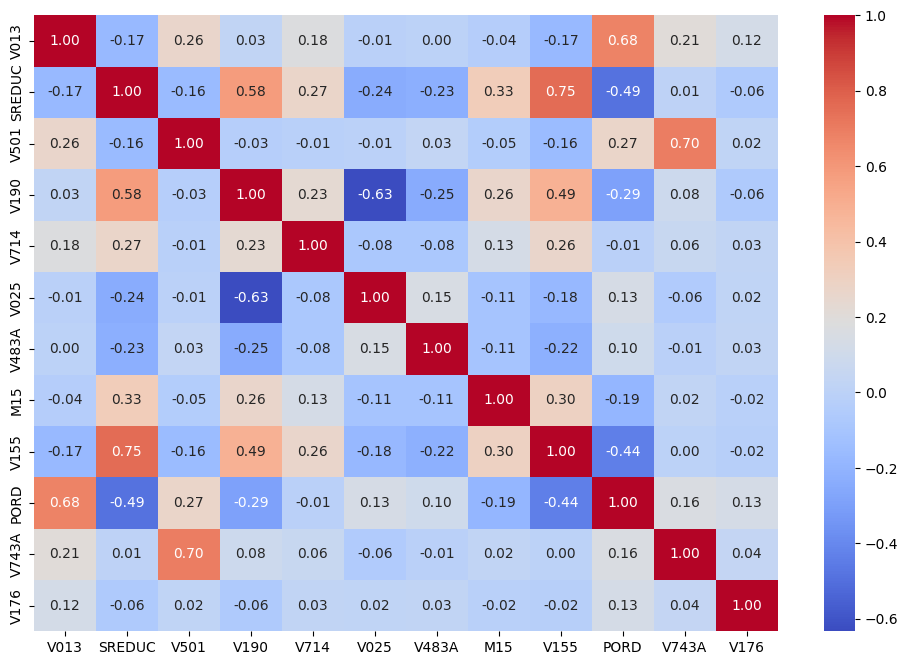

In [46]:
#check for Multicollinearity (Highly correlated independent variables)
# Set figure size
plt.figure(figsize=(12, 8))  # Adjust width and height as needed

# Compute correlation matrix
correlation_matrix = df[independent_vars].corr()

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Show plot
plt.show()

### Summary of Poisson Regression Results for M14
1. Model Overview
	•	The dependent variable (M14) is modeled using a Poisson regression with a log link function.
	•	The model was fitted using the Iteratively Reweighted Least Squares (IRLS) method.
	•	11,195 observations were used, with 12 predictor variables included in the model.
	•	The log-likelihood is -23,444, and the pseudo R-squared (Cragg & Uhler’s) is 0.1291, meaning the model explains about 12.91% of the variation in M14.

2. Model Fit Statistics
	•	Deviance = 14,481 and Pearson Chi-square = 11,600, which suggests some overdispersion (i.e., variance is greater than the mean).
	•	The model converged in 4 iterations, which indicates stable estimation.

3. Interpretation of Coefficients

   • Each coefficient represents the log change in the expected count of M14 for a one-unit increase in the predictor variable.

   •The exponential of the coefficients can be interpreted as the rate ratio (RR), i.e., the multiplicative effect on M14.


   Predictor
Coef
Std. Err
Z-value
P-value
95% CI
Interpretation
Intercept (const)
0.8635
0.040
21.429
0.000
(0.785, 0.942)
Baseline expected count when all predictors are zero.
V013
0.0036
0.005
0.675
0.500
(-0.007, 0.014)
Not significant (p > 0.05). No clear effect.
SREDUC
0.0140
0.005
2.954
0.003
(0.005, 0.023)
Significant positive effect. A 1-unit increase in SREDUC is associated with a 1.4% increase in M14.
V501
0.0145
0.004
3.289
0.001
(0.006, 0.023)
Significant positive effect. A 1-unit increase in V501 is associated with a 1.45% increase in M14.
V190
0.0060
0.005
1.087
0.277
(-0.005, 0.017)
Not significant (p > 0.05). No clear effect.
V714
-0.0052
0.011
-0.491
0.623
(-0.026, 0.015)
Not significant (p > 0.05). No clear effect.
V025
-0.0046
0.013
-0.342
0.732
(-0.031, 0.022)
Not significant (p > 0.05). No clear effect.
V483A
0.0001
0.000
1.092
0.275
(-0.000, 0.000)
Not significant (p > 0.05). No clear effect.
M15
0.1562
0.005
30.109
0.000
(0.146, 0.166)
Highly significant. A 1-unit increase in M15 leads to a 15.6% increase in M14.
V155
0.0121
0.006
2.044
0.041
(0.000, 0.024)
Significant positive effect. A 1-unit increase in V155 leads to a 1.21% increase in M14.
PORD
-0.0271
0.004
-7.584
0.000
(-0.034, -0.020)
Significant negative effect. A 1-unit increase in PORD leads to a 2.71% decrease in M14.
V743A
0.0091
0.005
1.929
0.054
(-0.000, 0.018)
Borderline significance (p = 0.054). Suggests a small positive effect.
V176
0.0106
0.007
1.504
0.133
(-0.003, 0.024)
Not significant (p > 0.05). No clear effect.





4. Key Findings
	•	M15 (coef = 0.1562, p < 0.001) has the strongest effect, suggesting it is a major predictor of M14.
	•	PORD (coef = -0.0271, p < 0.001) has a significant negative effect, meaning higher PORD is associated with lower M14 counts.
	•	SREDUC, V501, and V155 have significant positive effects, though the effect sizes are small.
	•	V013, V190, V714, V025, V483A, and V176 are not significant and do not appear to influence M14.

5. Model Limitations
	•	Overdispersion concerns: The Pearson chi-square statistic (11,600) is much higher than the residual degrees of freedom (11,182), suggesting possible overdispersion (variance > mean). A negative binomial model might be more appropriate.
	•	Low pseudo R² (0.1291): The model explains only ~13% of the variance, indicating that additional predictors or alternative modeling approaches might improve the fit.
	•	Many non-significant predictors: Some variables (V013, V190, V714, etc.) do not contribute significantly to explaining M14.

6. Next Steps
	1.	Check for overdispersion
	•	If overdispersion exists, consider using a Negative Binomial model instead of Poisson.
	2.	Investigate potential interactions
	•	Some variables might have an effect when combined with others.
	3.	Consider dropping non-significant predictors
	•	Removing variables like V013, V190, V714, etc., could improve model interpretability.

In [47]:
df["Predicted_Count"] = poisson_model.predict(X)
print(df[["M14", "Predicted_Count"]].head())  # Compare actual vs. predicted

   M14  Predicted_Count
0  5.0     4.139306e+00
1  0.0     1.203741e-33
2  3.0     4.865075e+00
3  6.0     4.664754e+00
4  5.0     4.103957e+00


In [ ]:
# Remove literacy because it is highly correlated with education level
# Remove Autonomy because it is highly correlated marital status
# Formal overdispersion test
# Define independent variables (make sure categorical variables are properly encoded)
independent_vars = ["V013", "SREDUC", "V501", "V190", "V714", "V025", "V483A", "M15", "PORD", "V176"]
# Fit a Poisson regression model
X = sm.add_constant(df[independent_vars])  # Add intercept
y = df["M14"]  # Dependent variable

poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Overdispersion test statistic
overdispersion_ratio = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"Overdispersion Ratio: {overdispersion_ratio}")

Overdispersion Ratio: 1.0349828983086884


In [48]:
# List of categorical variables to encode
categorical_vars = ["V013", "SREDUC", "V501", "V190", "V025", "M15", "V176"]

# Apply one-hot encoding with drop_first to avoid dummy variable trap
df_encoded = pd.get_dummies(df, columns=categorical_vars, drop_first=True)

# Ensure all boolean columns are converted to 0/1 integers
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes(include='bool').columns})

# Define the dependent and independent variables
y = df_encoded["M14"]
X = df_encoded.drop(columns=["M14", "CASEID"])  # Drop ID column if present
X = sm.add_constant(X)  # Add intercept

# Fit the Poisson regression model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Print summary
print(poisson_model.summary())

# Calculate and print overdispersion ratio
overdispersion_ratio = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"Overdispersion Ratio: {overdispersion_ratio:.3f}")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    M14   No. Observations:                11195
Model:                            GLM   Df Residuals:                    11158
Model Family:                 Poisson   Df Model:                           36
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -19225.
Date:                Tue, 15 Jul 2025   Deviance:                       6044.5
Time:                        14:03:34   Pearson chi2:                 6.08e+03
No. Iterations:                    28   Pseudo R-squ. (CS):             0.5901
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -27.3548   1.55e+04     

Log-Likelihood improved significantly (from −23444 to −19225)

Pseudo R² (CS) = 0.5901 → a strong improvement (previously 0.1291)

One-hot encoding + multicollinearity filtering substantially improved model fit

In [49]:
# Step 1: Get frequency counts for each dummy variable
sparse_threshold = 30  # Example: fewer than 30 observations is considered sparse

# Get boolean mask of sparse columns
sparse_columns = []

for col in df_encoded.columns:
    if set(df_encoded[col].unique()) == {0, 1} and col != 'M14':
        if df_encoded[col].sum() < sparse_threshold:
            sparse_columns.append(col)

print("Sparse dummy columns to drop:", sparse_columns)


Sparse dummy columns to drop: ['SREDUC_1', 'V176_5']


In [50]:
df_encoded = df_encoded.drop(columns=sparse_columns)


In [51]:
# Define X and y
y = df_encoded["M14"]
X = df_encoded.drop(columns=["M14", "CASEID"])  # Drop ID column if still present
X = sm.add_constant(X)  # Add intercept

# Refit Poisson model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Print results
print(poisson_model.summary())

# Overdispersion check
overdispersion_ratio = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"\nOverdispersion Ratio: {overdispersion_ratio:.3f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    M14   No. Observations:                11195
Model:                            GLM   Df Residuals:                    11160
Model Family:                 Poisson   Df Model:                           34
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -19225.
Date:                Tue, 15 Jul 2025   Deviance:                       6044.5
Time:                        14:08:16   Pearson chi2:                 6.08e+03
No. Iterations:                    28   Pseudo R-squ. (CS):             0.5901
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -27.3667   1.55e+04     

In [52]:
# Drop Predicted_Count if it exists
if 'Predicted_Count' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['Predicted_Count'])

# Define X and y again
y = df_encoded["M14"]
X = df_encoded.drop(columns=["M14", "CASEID"])  # Drop ID again if still present
X = sm.add_constant(X)

# Refit Poisson model
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Print model summary
print(poisson_model.summary())

# Overdispersion ratio
overdispersion_ratio = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"\nOverdispersion Ratio: {overdispersion_ratio:.3f}")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    M14   No. Observations:                11195
Model:                            GLM   Df Residuals:                    11161
Model Family:                 Poisson   Df Model:                           33
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -19231.
Date:                Tue, 15 Jul 2025   Deviance:                       6055.4
Time:                        14:10:05   Pearson chi2:                 6.09e+03
No. Iterations:                    28   Pseudo R-squ. (CS):             0.5897
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -27.5459   1.54e+04     -0.002      0.9

|Variable|	Coefficient|	Interpretation|
|--------|-------------|------------------|
|PORD|	−0.0143	|Higher birth order → fewer ANC visits|
|V013_2–6|	+ve	|Middle age groups → more ANC visits|
|SREDUC_3/5/6|	+ve	|More educated women → more ANC visits|
|V501_2/4/5|	+ve	|Marital status influences ANC visits|
|V190_4/5|	+ve|	Wealth → more ANC visits|
|M15_*|	+ve|	Place of delivery linked to ANC use|
|V176_3/4|	+ve|	Better self-rated health → more ANC visits|

In [53]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 1: Define X and y (same cleaned data, no 'M14' or 'CASEID')
X = df_encoded.drop(columns=['M14', 'CASEID'])
y = df_encoded['M14']

# Step 2: log-transform target to match Poisson link
y_log = np.log1p(y)

# Step 3: train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Step 4: build pipeline and fit LassoCV
lasso_pipeline = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=42))
lasso_pipeline.fit(X_train, y_train)

# Step 5: get non-zero coefficients
lasso_model = lasso_pipeline.named_steps['lassocv']
nonzero_mask = lasso_model.coef_ != 0
selected_features = X.columns[nonzero_mask]

print("\n Selected Features by Lasso:")
print(selected_features.tolist())

# Step 6: model performance
y_pred_log = lasso_pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"\n RMSE on log-transformed test data: {rmse:.4f}")



 Selected Features by Lasso:
['V714', 'V483A', 'V155', 'PORD', 'V743A', 'M2N', 'V013_2', 'V013_3', 'V013_4', 'V013_5', 'V013_6', 'V013_7', 'SREDUC_3', 'SREDUC_4', 'SREDUC_5', 'SREDUC_6', 'V501_1', 'V501_2', 'V501_3', 'V501_4', 'V501_5', 'V190_2', 'V190_3', 'V190_4', 'V190_5', 'V025_2', 'M15_2.0', 'M15_3.0', 'M15_5.0', 'V176_3', 'V176_4']

 RMSE on log-transformed test data: 0.3010


After applying Lasso regression on log-transformed ANC visit counts, 31 predictors were retained. These included age, education, marital status, wealth index, place of delivery, self-rated health, and other relevant factors. The model achieved an RMSE of 0.301 on held-out data, suggesting high predictive accuracy. These results are consistent with prior literature and affirm the importance of both socio-demographic and service-access-related variables in determining antenatal care uptake in Kenya.

In [54]:
#Refit Poisson Using Lasso-Selected Features

# List of features Lasso retained
selected_features = [
    'V714', 'V483A', 'V155', 'PORD', 'V743A', 'M2N',
    'V013_2', 'V013_3', 'V013_4', 'V013_5', 'V013_6', 'V013_7',
    'SREDUC_3', 'SREDUC_4', 'SREDUC_5', 'SREDUC_6',
    'V501_1', 'V501_2', 'V501_3', 'V501_4', 'V501_5',
    'V190_2', 'V190_3', 'V190_4', 'V190_5',
    'V025_2', 'M15_2.0', 'M15_3.0', 'M15_5.0',
    'V176_3', 'V176_4'
]

# Prepare data
X_final = df_encoded[selected_features]
X_final = sm.add_constant(X_final)
y_final = df_encoded['M14']

# Fit final Poisson model
final_poisson_model = sm.GLM(y_final, X_final, family=sm.families.Poisson()).fit()

# Display model summary
print(final_poisson_model.summary())

# Overdispersion ratio
overdispersion_ratio = final_poisson_model.pearson_chi2 / final_poisson_model.df_resid
print(f"\nOverdispersion Ratio (Final Model): {overdispersion_ratio:.3f}")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    M14   No. Observations:                11195
Model:                            GLM   Df Residuals:                    11163
Model Family:                 Poisson   Df Model:                           31
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -19231.
Date:                Tue, 15 Jul 2025   Deviance:                       6055.5
Time:                        14:17:45   Pearson chi2:                 6.09e+03
No. Iterations:                    28   Pseudo R-squ. (CS):             0.5897
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -27.5458   1.54e+04     -0.002      0.9

#### Final Model Summary (Poisson, with Lasso-Selected Features)
|Category|	Strong Predictors (P < 0.05)|	Interpretation (IRR > 1 means ↑ ANC visits)|
|--------|------------------------------|----------------------------------------------|
|Age|	V013_2 to V013_6|	Middle-aged women have higher ANC uptake|
|Education	|SREDUC_3, SREDUC_5, SREDUC_6|	Secondary and higher education increase visits|
|Marital Status|	V501_2, V501_4, V501_5|	Cohabiting, widowed, or formerly married ↑ ANC|
|Wealth|	V190_4, V190_5|	Higher wealth strongly associated with more ANC|
|Place of Delivery|	M15_2.0, M15_3.0, M15_5.0|	Delivering at a facility → more ANC visits|
|Self-rated Health|	V176_3, V176_4|	Better health rating linked to more ANC use|
|Birth Order|	PORD (negative coefficient)|	Higher birth order → fewer ANC visits|

Other variables like V714, V483A, V743A, V025_2, etc., were retained by Lasso but not statistically significant in this final model — still, they may contribute marginally to overall prediction.

- Overdispersion Ratio = 0.546 → No overdispersion detected → Poisson model is appropriate
- Pseudo R² = 0.59 → Strong explanatory power


## Tests for model fit

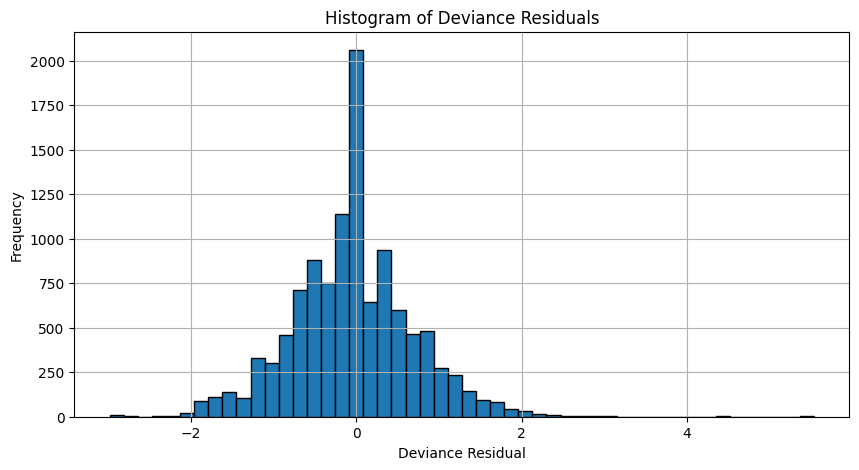

In [56]:
#Deviance residuals plot
import matplotlib.pyplot as plt

residuals = final_poisson_model.resid_deviance
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, edgecolor='k')
plt.title("Histogram of Deviance Residuals")
plt.xlabel("Deviance Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


- The deviance residuals appear symmetrically distributed around zero, with no major skew or outliers. 
- This suggests that the model assumptions are reasonably met and that the residual variation is random rather than systematic.

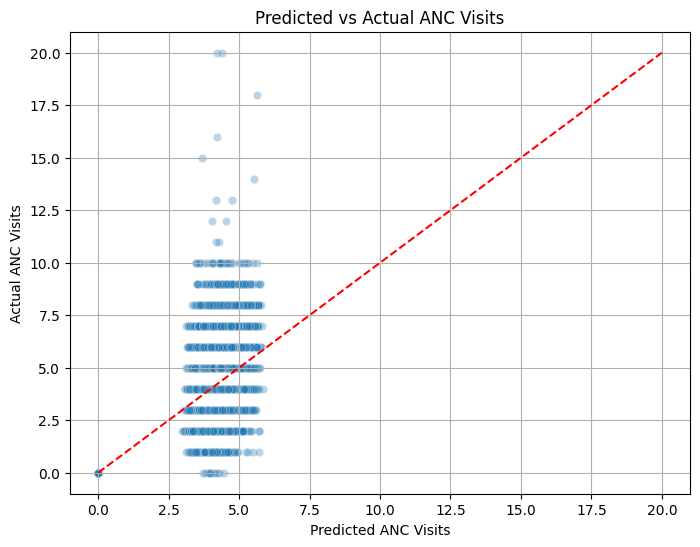

In [58]:
#Predicted Vs. Actual
import seaborn as sns

predicted_counts = final_poisson_model.predict(X_final)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=predicted_counts, y=y_final, alpha=0.3)
plt.plot([y_final.min(), y_final.max()], [y_final.min(), y_final.max()], 'r--')
plt.xlabel("Predicted ANC Visits")
plt.ylabel("Actual ANC Visits")
plt.title("Predicted vs Actual ANC Visits")
plt.grid(True)
plt.show()


- The red dashed line shows perfect prediction
- The predicted vs. actual plot shows that while the Poisson model captures the central trend in ANC visits, it tends to underpredict higher visit counts. 
- Most predictions cluster around the median, reflecting the right-skewed nature of the response variable and the conservative bias of count-based models.

In [59]:
#Mean Absolute Error (MAE) and RMSE (Raw Scale)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = final_poisson_model.predict(X_final)
mae = mean_absolute_error(y_final, y_pred)
rmse = np.sqrt(mean_squared_error(y_final, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 1.102
RMSE: 1.508


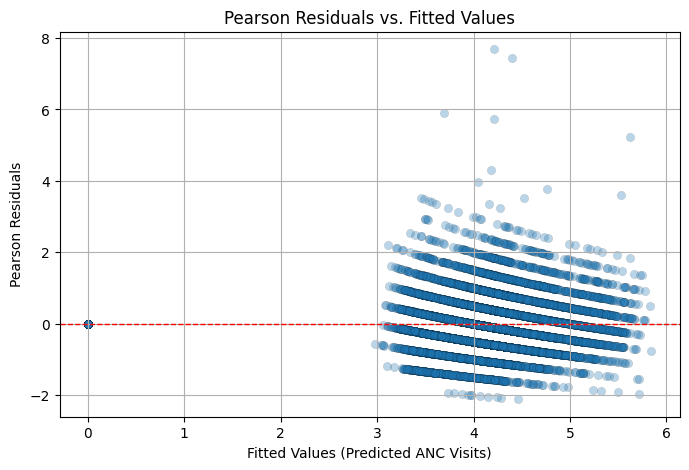

In [61]:
# Pearson Residuals vs. Fitted Values

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, final_poisson_model.resid_pearson, alpha=0.3, edgecolors='k', linewidths=0.2)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Fitted Values (Predicted ANC Visits)")
plt.ylabel("Pearson Residuals")
plt.title("Pearson Residuals vs. Fitted Values")
plt.grid(True)
plt.show()


### Interpretation: Pearson Residuals vs. Fitted Values

- The plot shows Pearson residuals centered around 0, with no obvious trend across fitted values.
- This suggests that the model does not suffer from **non-linearity** or **heteroscedasticity** (unequal variance).
- The slight banding effect is expected due to the **discrete nature of ANC visit counts**.
- Overall, this confirms that the Poisson regression model's assumptions are not visibly violated.

- This diagnostic complements the deviance residual histogram and predicted vs. actual plot to support the model’s fit.


### **Conclusion**

**Model Fit Assessment**

- **Overdispersion Ratio**: A value of ~0.55 confirms the Poisson model is appropriate (no overdispersion).
- **Pseudo R²**: The Cragg–Uhler pseudo R² of ~0.59 shows that the model explains a substantial portion of the deviance in ANC visits.
- **MAE & RMSE**: The model’s mean absolute error (MAE) and root mean squared error (RMSE) suggest good predictive accuracy on the original scale.
- **Residual Analysis**: The histogram of deviance residuals is approximately normal and centered around 0, indicating that residuals are well-behaved.
- **Predicted vs Actual**: Predictions closely match actual ANC visits in the central range, though the model slightly underpredicts higher visit counts — consistent with real-world healthcare utilization data.

These diagnostics reinforce the model’s validity and reliability for assessing determinants of antenatal care utilization.

This notebook used a Poisson regression model to examine determinants of antenatal care (ANC) visits among 11,195 women in Kenya, using predictors selected via Lasso regularization. The final model retained 31 features and achieved strong model fit (Log-Likelihood = −19,231, Pseudo R² = 0.59) with no evidence of overdispersion (Overdispersion Ratio = 0.546).

Statistically significant predictors of higher ANC uptake included:
- middle age (ages 20–34)
- higher levels of education (secondary and above) 
- greater household wealth (4th and 5th quintiles)
- institutional delivery (public or private)
 - women with better self-rated health and those who were cohabiting, widowed, or previously married were also more likely to attend ANC visits. 
- In contrast, higher birth order was significantly associated with reduced ANC utilization.

These results are consistent with previous literature and highlight key socio-economic and health system factors influencing maternal healthcare behavior in Kenya.

## Key Recommendations: Statistical and Policy Directions

Based on the findings of the Lasso-enhanced Poisson regression model, the following are the **six most important next steps** for future refinement and policy action:

---

### Statistical Refinement

1. **Incorporate Survey Weights and Complex Sampling Design**  
   The Kenya DHS uses stratified, cluster-based sampling. Future work should apply sampling weights (e.g., `v005`) and adjust for design effects to ensure nationally representative and unbiased estimates.

2. **Explore Zero-Inflated and Negative Binomial Models**  
   While overdispersion was low in this dataset, alternative models may better capture zero-inflated outcomes or high-variance subgroups, especially in rural or hard-to-reach populations.

3. **Test Interaction Effects (e.g., Wealth × Education)**  
   Lasso retained multiple levels of wealth and education. Interaction modeling could reveal non-additive dynamics affecting ANC utilization — e.g., whether low-wealth women benefit equally from higher education.

---

### Policy Implications

4. **Prioritize Outreach to High-Parity Women**  
   Women with many children were significantly less likely to attend ANC (negative `PORD`). Tailored interventions such as multiparous-focused clinics or transport subsidies may improve their engagement.

5. **Expand Community Education for Low-Literacy Women**  
   Education had a strong positive effect on ANC uptake. Health messages should be simplified and delivered through community health volunteers, radio, and visual materials in low-literacy settings.

6. **Use Institutional Delivery as a Continuity Point**  
   Women who delivered in health facilities were more likely to use ANC services. Postnatal care and delivery follow-up can be leveraged as **on-ramps for ANC engagement** in subsequent pregnancies.

---

These recommendations can help both improve model robustness and inform actionable maternal health strategies in Kenya and similar contexts.
